# Laboratory Assignment 04
## Generative AI — Basic GAN using MNIST

**Name:** Rudra Pratap Singh  
**Roll No.:** 23SCSE1180423  
**Course:** Generative AI  
**Course Code:** R1UD702B  
**Program:** B.Tech. (AIML)  
**Semester:** 7th  
**Academic Year:** 2026–27  

### Objective
To implement a basic Generative Adversarial Network (GAN) using PyTorch
for generating synthetic handwritten digit images from the MNIST dataset.

## Import Required Libraries

The following libraries are used for building, training and visualizing
the GAN model.

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

print("PyTorch Version:", torch.__version__)
print("Libraries imported successfully.")

PyTorch Version: 2.11.0+cpu
Libraries imported successfully.


## Q1: Generate Random Noise and Fake Images

### Step 1: Load the MNIST Dataset

MNIST contains grayscale handwritten digit images belonging to
digits 0 to 9. The images have a size of 28 × 28 pixels.

In [2]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# Image transformation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load MNIST dataset
dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Create DataLoader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

print("Number of training images:", len(dataset))
print("Dataset loaded successfully.")

Using device: cpu


100%|██████████| 9.91M/9.91M [00:01<00:00, 6.57MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 154kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.2MB/s]

Number of training images: 60000
Dataset loaded successfully.


### Step 2: Create Random Noise

A latent vector of dimension 100 is used as random noise.
The Generator receives this noise vector as input.

In [3]:
latent_dim = 100

# Generate one random noise vector
noise = torch.randn(1, latent_dim, device=device)

print("Latent dimension:", latent_dim)
print("Noise vector shape:", noise.shape)

Latent dimension: 100
Noise vector shape: torch.Size([1, 100])


### Step 3: Define the Generator

The Generator takes a 100-dimensional random noise vector and transforms
it into a 28 × 28 grayscale image.

In [4]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(True),

            nn.Linear(256, 512),
            nn.ReLU(True),

            nn.Linear(512, 1024),
            nn.ReLU(True),

            nn.Linear(1024, 28 * 28),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.model(x)
        return x.view(-1, 1, 28, 28)


generator = Generator(latent_dim).to(device)

print(generator)

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)


### Step 4: Generate 16 Fake Images

Random noise vectors are passed through the Generator to create
16 synthetic MNIST-like images.

Generated image tensor shape: torch.Size([16, 1, 28, 28])


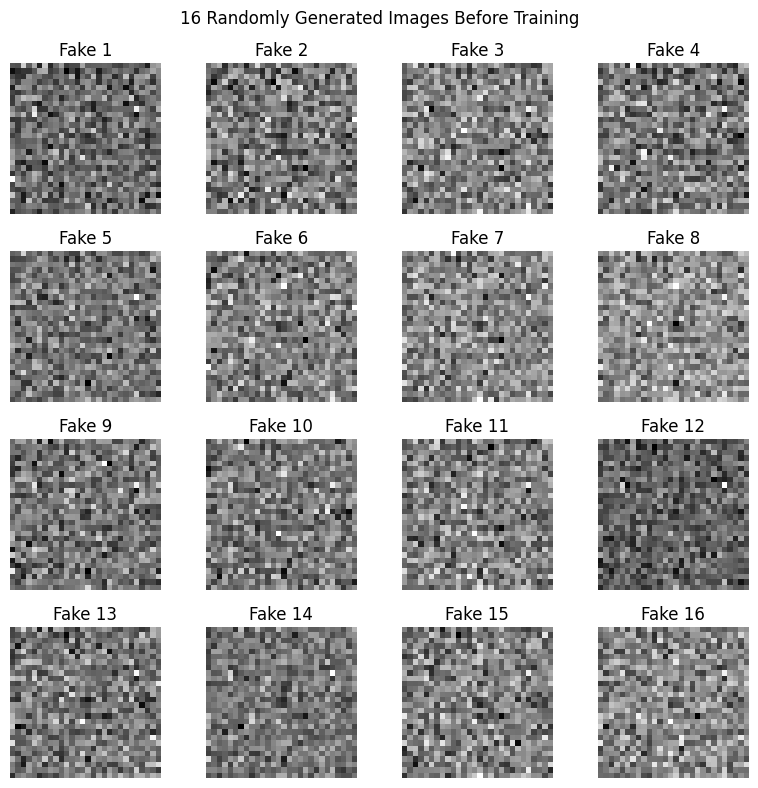

In [5]:
# Generate 16 random noise vectors
noise = torch.randn(16, latent_dim, device=device)

# Generate fake images
with torch.no_grad():
    fake_images = generator(noise)

print("Generated image tensor shape:", fake_images.shape)

# Display generated images
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flatten()):
    image = fake_images[i].cpu().squeeze().numpy()

    ax.imshow(image, cmap="gray")
    ax.axis("off")
    ax.set_title(f"Fake {i+1}")

plt.suptitle("16 Randomly Generated Images Before Training")
plt.tight_layout()
plt.show()

Generated image tensor shape: torch.Size([16, 1, 28, 28])


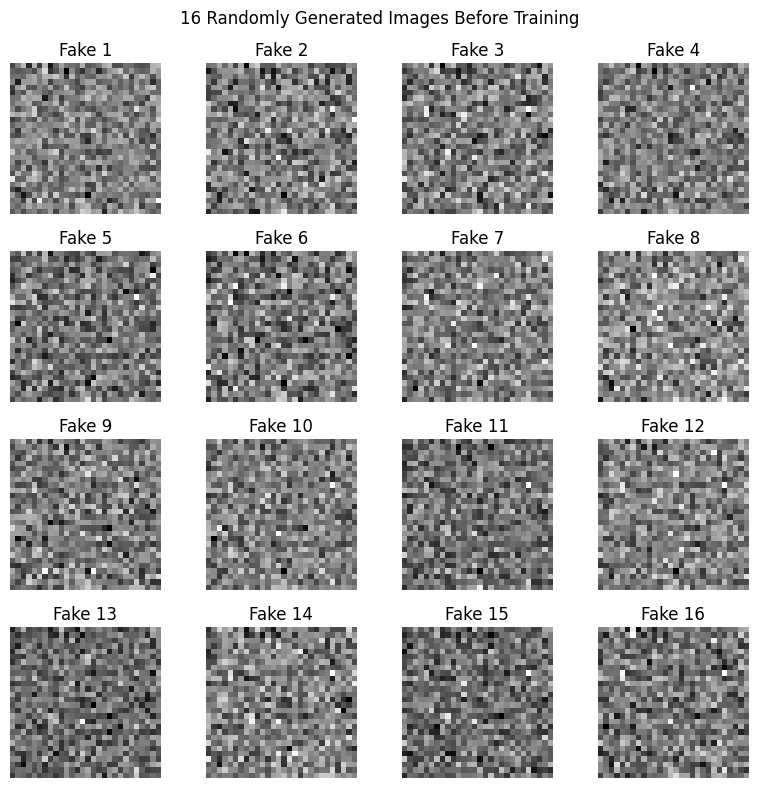

In [6]:
# Generate 16 random noise vectors
noise = torch.randn(16, latent_dim, device=device)

# Generate fake images
with torch.no_grad():
    fake_images = generator(noise)

print("Generated image tensor shape:", fake_images.shape)

# Display generated images
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flatten()):
    image = fake_images[i].cpu().squeeze().numpy()

    ax.imshow(image, cmap="gray")
    ax.axis("off")
    ax.set_title(f"Fake {i+1}")

plt.suptitle("16 Randomly Generated Images Before Training")
plt.tight_layout()
plt.show()

## Q2: Implement and Train a Basic GAN

A GAN consists of two neural networks:

- **Generator:** Creates fake images from random noise.
- **Discriminator:** Determines whether an image is real or fake.

The two networks are trained together in an adversarial process.

### Step 1: Define the Discriminator

The Discriminator receives a 28 × 28 image and outputs a probability
between 0 and 1 indicating whether the image is real.

In [7]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        return self.model(x)


discriminator = Discriminator().to(device)

print(discriminator)

Discriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


### Step 2: Define Loss Function and Optimizers

Binary Cross Entropy (BCELoss) is used to measure the classification
error of the Discriminator.

Adam optimizer is used to update both the Generator and Discriminator.

In [8]:
criterion = nn.BCELoss()

learning_rate = 0.0002

optimizer_G = optim.Adam(
    generator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)

print("Loss Function: BCELoss")
print("Optimizer: Adam")
print("Learning Rate:", learning_rate)

Loss Function: BCELoss
Optimizer: Adam
Learning Rate: 0.0002


GAN Training

### Step 3: Train the GAN

The GAN is trained for 10 epochs.

For each batch:

1. The Discriminator learns from real MNIST images.
2. The Generator creates fake images.
3. The Discriminator learns to identify fake images.
4. The Generator learns to produce images that can fool the Discriminator.

In [9]:
num_epochs = 10

G_losses = []
D_losses = []

for epoch in range(num_epochs):

    for real_images, _ in dataloader:

        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        # Labels
        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # ---------------------------------
        # Train Discriminator
        # ---------------------------------

        optimizer_D.zero_grad()

        # Real images
        real_output = discriminator(real_images)
        loss_real = criterion(real_output, real_labels)

        # Fake images
        noise = torch.randn(batch_size, latent_dim, device=device)
        fake_images = generator(noise)

        fake_output = discriminator(fake_images.detach())
        loss_fake = criterion(fake_output, fake_labels)

        # Total discriminator loss
        loss_D = loss_real + loss_fake

        loss_D.backward()
        optimizer_D.step()

        # ---------------------------------
        # Train Generator
        # ---------------------------------

        optimizer_G.zero_grad()

        noise = torch.randn(batch_size, latent_dim, device=device)
        generated_images = generator(noise)

        output = discriminator(generated_images)

        # Generator wants discriminator to classify fake images as real
        loss_G = criterion(output, real_labels)

        loss_G.backward()
        optimizer_G.step()

        # Store losses
        G_losses.append(loss_G.item())
        D_losses.append(loss_D.item())

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss D: {loss_D.item():.4f} | "
        f"Loss G: {loss_G.item():.4f}"
    )

print("\nGAN training completed successfully.")

Epoch [1/10] Loss D: 0.5815 | Loss G: 1.1226
Epoch [2/10] Loss D: 0.4976 | Loss G: 2.7172
Epoch [3/10] Loss D: 1.1800 | Loss G: 5.1067
Epoch [4/10] Loss D: 0.5226 | Loss G: 2.9282
Epoch [5/10] Loss D: 1.0270 | Loss G: 1.3298
Epoch [6/10] Loss D: 0.1864 | Loss G: 3.8622
Epoch [7/10] Loss D: 0.3429 | Loss G: 2.7920
Epoch [8/10] Loss D: 0.2928 | Loss G: 3.7382
Epoch [9/10] Loss D: 0.6162 | Loss G: 2.9077
Epoch [10/10] Loss D: 0.2597 | Loss G: 5.9373

GAN training completed successfully.


Q3. Generate Synthetic Images and Visualize Training

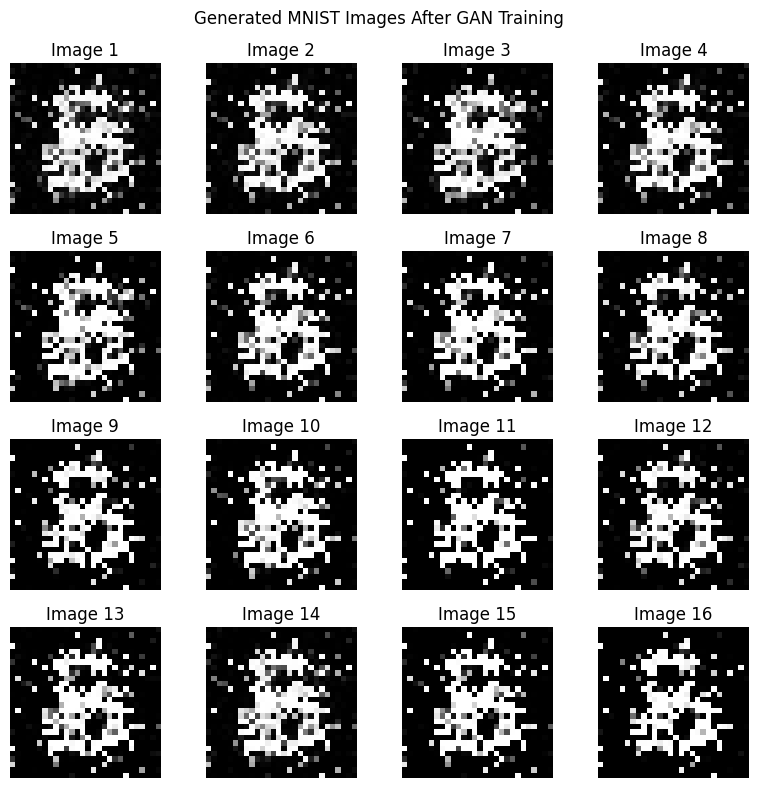

In [10]:
# Generate final 16 images
generator.eval()

with torch.no_grad():
    noise = torch.randn(16, latent_dim, device=device)
    final_images = generator(noise)

# Display final generated images
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flatten()):
    image = final_images[i].cpu().squeeze().numpy()

    ax.imshow(image, cmap="gray")
    ax.axis("off")
    ax.set_title(f"Image {i+1}")

plt.suptitle("Generated MNIST Images After GAN Training")
plt.tight_layout()
plt.show()

Loss Curves

### Generator and Discriminator Loss Curves

The loss curves show how the Generator and Discriminator losses change
during GAN training.

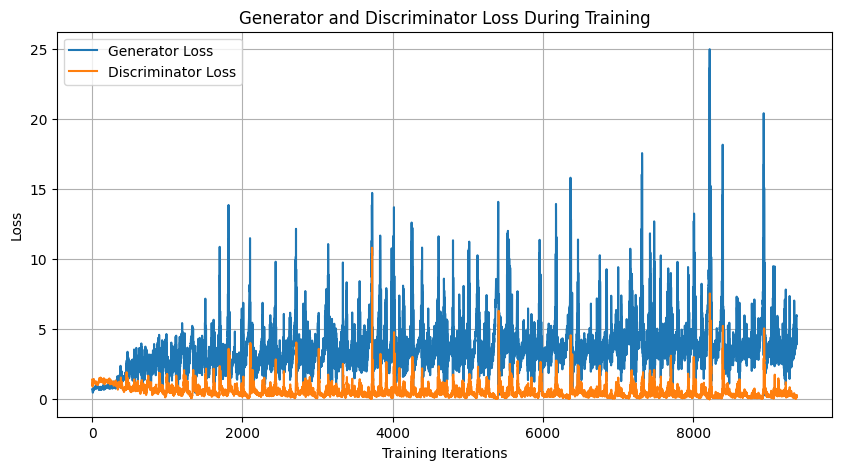

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")

plt.title("Generator and Discriminator Loss During Training")
plt.xlabel("Training Iterations")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

## Observations

1. Before training, the Generator produces random noise-like images because
   it has not yet learned the patterns of handwritten digits from MNIST.

2. After 10 epochs of adversarial training, the Generator produces images
   that show recognizable MNIST-like digit patterns.

3. The Discriminator learns to distinguish real MNIST images from generated
   images, while the Generator continuously improves its ability to produce
   realistic synthetic images.

4. The Generator and Discriminator loss curves show the changing behaviour
   of both networks during the adversarial training process.

## Conclusion

In this laboratory assignment, a basic Generative Adversarial Network (GAN)
was implemented using PyTorch and trained on the MNIST handwritten digit
dataset.

A random 100-dimensional latent noise vector was used as input to the
Generator. The Generator produced 28 × 28 grayscale images, while the
Discriminator classified images as real or fake.

Binary Cross Entropy (BCELoss) and the Adam optimizer were used for training.
The GAN was trained for 10 epochs. Finally, 16 synthetic images were
generated and displayed in a 4 × 4 grid, and the Generator and Discriminator
loss curves were plotted using Matplotlib.

The experiment demonstrates the basic working principle of a GAN, where
the Generator and Discriminator learn simultaneously through an adversarial
training process.